# Waddington-OT between consecutive single-cell snapshots

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2026 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:kantorovich-waddington-ot`. It illustrates the Waddington-OT coupling between serum iPSC reprogramming cells collected at days 10 and 10.5 in the public dataset of Schiebinger et al. The two populations are represented by empirical measures

$$
\alpha_{10}=\frac{1}{n_0}\sum_{i=1}^{n_0}\delta_{x_i},
\qquad
\alpha_{10.5}=\frac{1}{n_1}\sum_{j=1}^{n_1}\delta_{y_j},
$$

and visualized in a shared two-dimensional PCA space. The original Waddington-OT plan is unbalanced because it models cell growth; it is normalized only for sampling the representative paths shown here.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('IPython', 'ipython'),
)
_OT4ML_REQUIRED_FILES = (
    'notebooks-figures/assets/waddington_ot_day10_day10_5.npz',
)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT


In [2]:
from pathlib import Path
import shutil

from IPython.display import Image as DisplayImage
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgb
import numpy as np

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "kantorovich-waddington-ot"
OUT = figure_dir(NAME)
ASSET = FIGROOT / "assets" / "waddington_ot_day10_day10_5.npz"
THUMBNAIL = FIGROOT / "thumbnails" / f"{NAME}.png"
ARXIV_OUTPUT = ROOT / "arxiv" / "figures" / f"{NAME}--waddington-ot.pdf"
INTERPOLATION_TIMES = np.array([0.0, 1.0 / 3.0, 2.0 / 3.0, 1.0])


## Shared PCA coordinates and reduced public asset

The official tutorial archives contain the log-normalized expression matrix and precomputed transport maps. The companion script `prepare_waddington_ot_data.py` extracts only the required archive members by HTTP byte ranges, fits PCA jointly to the two consecutive snapshots, and writes the compact asset loaded below. The first two principal components explain the fractions of pairwise variance reported by the notebook.

For legibility, the observed red and blue endpoint clouds are each thinned to 500 cells by deterministic farthest-point sampling. No cell identifier or expression vector is stored in the reduced asset; see `assets/waddington_ot_day10_day10_5_provenance.md` for exact provenance.

In [3]:
def load_reduced_waddington_data(path: Path) -> dict[str, np.ndarray]:
    """Load and validate the compact Waddington-OT plotting asset.

    Args:
        path: Repository-local NPZ file prepared from the official tutorial data.

    Returns:
        Dictionary containing endpoint PCA coordinates, display subsets,
        representative plan atoms, high-mass segments, and metadata.

    Raises:
        FileNotFoundError: If the reduced asset is unavailable.
        ValueError: If a coordinate or index array has an invalid shape.
    """
    if not path.exists():
        raise FileNotFoundError(f"Missing Waddington-OT asset: {path}")
    with np.load(path) as archive:
        data = {name: archive[name] for name in archive.files}

    for name in ("source", "target"):
        if data[name].ndim != 2 or data[name].shape[1] != 2:
            raise ValueError(f"{name} must contain planar PCA coordinates")
    for name in (
        "source_display",
        "target_display",
        "pair_source",
        "pair_target",
        "segment_source",
        "segment_target",
    ):
        if data[name].ndim != 1:
            raise ValueError(f"{name} must be a one-dimensional index array")
    if len(data["pair_source"]) != len(data["pair_target"]):
        raise ValueError("representative plan endpoint arrays must have equal length")
    if len(data["segment_source"]) != len(data["segment_target"]):
        raise ValueError("segment endpoint arrays must have equal length")
    return data


data = load_reduced_waddington_data(ASSET)
source = data["source"]
target = data["target"]
source_day = float(data["source_day"])
target_day = float(data["target_day"])
variance_percent = 100.0 * data["explained_variance_ratio"]
print(
    f"{len(source):,} day-{source_day:g} cells, "
    f"{len(target):,} day-{target_day:g} cells; "
    f"PC1/PC2 explain {variance_percent[0]:.1f}%/{variance_percent[1]:.1f}% of variance."
)


2,051 day-10 cells, 1,941 day-10.5 cells; PC1/PC2 explain 12.5%/3.7% of variance.


## Sampling a soft coupling without visual clutter

Let $P_{ij}\geq 0$ be the Waddington-OT plan. To display its induced displacement interpolation, candidate pairs $(i,j)$ are sampled with probability proportional to $P_{ij}$ and then thinned by farthest-point sampling in the four-dimensional joint coordinate $(x_i,y_j)$. Each retained pair follows

$$
    z_{ij}(t)=(1-t)x_i+t y_j,
    \qquad 0\leq t\leq1.
$$

This preserves the soft-plan interpretation instead of replacing $P$ by a hard assignment. The coupling panel uses a second farthest-point pass among the largest entries of $P$, so its violet segments are both high-mass and spatially representative.

In [4]:
def common_limits(
    source_points: np.ndarray,
    target_points: np.ndarray,
    *,
    quantile: float = 0.0,
    padding: float = 0.04,
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Compute robust common limits for all PCA panels.

    Args:
        source_points: Source coordinates of shape ``(n, 2)``.
        target_points: Target coordinates of shape ``(m, 2)``.
        quantile: Tail fraction removed at each side before padding.
        padding: Fractional padding relative to the robust coordinate span.

    Returns:
        Horizontal and vertical plotting limits.
    """
    points = np.vstack([source_points, target_points])
    lower = np.quantile(points, quantile, axis=0)
    upper = np.quantile(points, 1.0 - quantile, axis=0)
    margin = padding * np.maximum(upper - lower, 1e-8)
    lower -= margin
    upper += margin
    return (lower[0], upper[0]), (lower[1], upper[1])


def draw_coupling_panel(ax: plt.Axes, dataset: dict[str, np.ndarray]) -> None:
    """Draw endpoint clouds and representative high-mass WOT links.

    Args:
        ax: Matplotlib axes receiving the coupling panel.
        dataset: Validated reduced Waddington-OT asset.
    """
    source_indices = dataset["segment_source"]
    target_indices = dataset["segment_target"]
    masses = dataset["segment_mass"]
    segments = np.stack(
        [source[source_indices], target[target_indices]],
        axis=1,
    )
    violet = np.asarray(to_rgb(VIOLET))
    # A small, spatially representative high-mass subset keeps the soft plan legible.
    segment_colors = [(*violet, 0.24 + 0.46 * np.sqrt(mass)) for mass in masses]
    ax.add_collection(
        LineCollection(
            segments,
            colors=segment_colors,
            linewidths=0.28 + 0.72 * np.sqrt(masses),
            zorder=1,
        )
    )
    source_display = dataset["source_display"]
    target_display = dataset["target_display"]
    ax.scatter(
        source[source_display, 0],
        source[source_display, 1],
        s=3.6,
        color=RED,
        alpha=0.68,
        linewidths=0,
        zorder=2,
    )
    ax.scatter(
        target[target_display, 0],
        target[target_display, 1],
        s=3.6,
        color=BLUE,
        alpha=0.64,
        linewidths=0,
        zorder=3,
    )
    ax.text(
        0.035,
        0.965,
        f"day {source_day:g}",
        color=RED,
        fontsize=7.2,
        ha="left",
        va="top",
        transform=ax.transAxes,
    )
    ax.text(
        0.965,
        0.965,
        f"day {target_day:g}",
        color=BLUE,
        fontsize=7.2,
        ha="right",
        va="top",
        transform=ax.transAxes,
    )


def draw_interpolation_panel(
    ax: plt.Axes,
    dataset: dict[str, np.ndarray],
    time: float,
) -> None:
    """Draw one sampled displacement interpolation of the WOT plan.

    Args:
        ax: Matplotlib axes receiving the point cloud.
        dataset: Validated reduced Waddington-OT asset.
        time: Interpolation parameter in ``[0, 1]``.
    """
    if not 0.0 <= time <= 1.0:
        raise ValueError("time must lie in [0, 1]")
    source_pairs = source[dataset["pair_source"]]
    target_pairs = target[dataset["pair_target"]]
    interpolated = (1.0 - time) * source_pairs + time * target_pairs
    ax.scatter(
        interpolated[:, 0],
        interpolated[:, 1],
        s=3.7,
        color=interp_color(time),
        alpha=0.78,
        linewidths=0,
    )
    if np.isclose(time, 0.0):
        title = r"$t=0$"
    elif np.isclose(time, 1.0):
        title = r"$t=1$"
    elif np.isclose(time, 1.0 / 3.0):
        title = r"$t=1/3$"
    else:
        title = r"$t=2/3$"
    ax.set_title(title, fontsize=8.3, pad=1.5)


def render_figure(dataset: dict[str, np.ndarray]) -> plt.Figure:
    """Render and export the coupling plus four interpolation snapshots.

    Args:
        dataset: Validated reduced Waddington-OT asset.

    Returns:
        Complete five-panel Matplotlib figure.
    """
    figure, axes = plt.subplots(1, 5, figsize=(7.25, 1.70))
    draw_coupling_panel(axes[0], dataset)
    axes[0].set_title("Waddington-OT coupling", fontsize=8.0, pad=1.5)
    for axis, time in zip(axes[1:], INTERPOLATION_TIMES):
        draw_interpolation_panel(axis, dataset, float(time))

    x_limits, y_limits = common_limits(source, target)
    for axis in axes:
        axis.set_xlim(*x_limits)
        axis.set_ylim(*y_limits)
        axis.set_aspect("equal", adjustable="box")
        remove_axes(axis)
    figure.subplots_adjust(
        left=0.004,
        right=0.996,
        bottom=0.015,
        top=0.89,
        wspace=0.035,
    )
    return figure


figure = render_figure(data)
output_path = OUT / "waddington-ot.pdf"
save_pdf(figure, output_path, pad_inches=0.015)
ARXIV_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(output_path, ARXIV_OUTPUT)
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(THUMBNAIL, dpi=220, bbox_inches="tight", pad_inches=0.015)
plt.close(figure)
print(f"Saved {output_path}")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/kantorovich-waddington-ot/waddington-ot.pdf


## Figure preview

The preview below is the same five-panel composition included in the book. Red-to-blue color interpolation marks displacement time, while the violet links in the first panel display a separate high-mass farthest-point subset of the coupling.

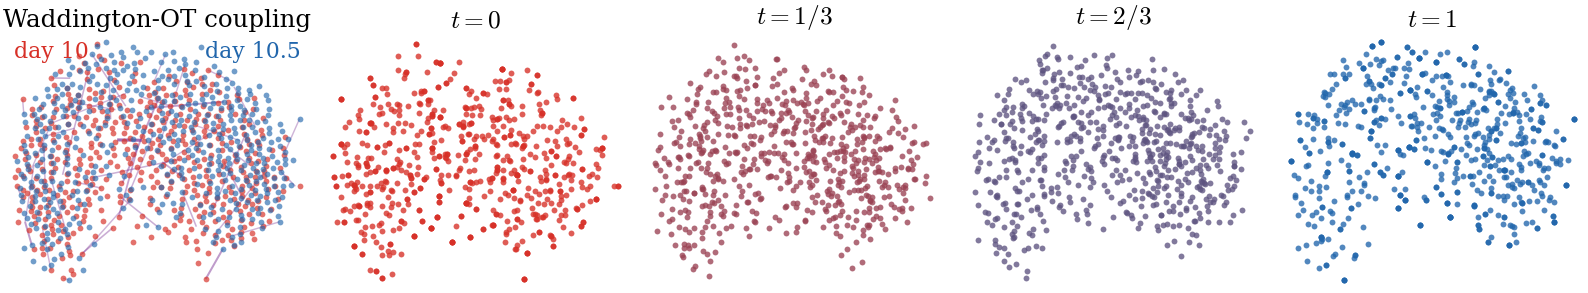

In [5]:
display(DisplayImage(filename=str(THUMBNAIL), width=1000))